In [1]:
import os
import time
import warnings
from datetime import datetime
from collections import OrderedDict
import numpy as np
import scipy
import sksparse.cholmod
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from utils_2_subdomains import construct_oras, Exp, set_seed, build_mmat
from utils_N_subdomains import decompose_domain, get_subdomains_endpoints

In [2]:
set_seed(42)
device = "cpu"
NUM_SUBDOMAINS = 10
ETA = 1
TOL = 1e-6
print(f"{NUM_SUBDOMAINS} subdomains")
method = 'mlp'
data = np.load("data_N_subdomains/data_mesh_squares_20-1000.npy", allow_pickle=True).item()
NUM_SAMPLES = 3
if method == 'mlp':
    NUM_TRAIN_SUBDOMAINS = 10
    mlp_pars = OrderedDict(
        [
        ("fc1", torch.nn.Linear(3, 64, dtype=torch.float64)),
        ("nl1", torch.nn.Sigmoid()),
        ("fc2", torch.nn.Linear(64, 32, dtype=torch.float64)),
        ("nl2", torch.nn.Sigmoid()),
        ("fc3", torch.nn.Linear(32, 2, dtype=torch.float64)),
        ("nl3", Exp())
        ]
    )
    mlp = torch.nn.Sequential(mlp_pars)
    # paramfile = f"results/train_meshrange_{NUM_TRAIN_SUBDOMAINS}_subdomains_lr0.005_20260401_133017/epoch_100"
    # paramfile = f"results/train_meshrange-tolvalid20_10_subdomains_lr0.005_20260402_203622/epoch_40"
    # paramfile = f"results/train_meshrange-tolvalid20-exp_10_subdomains_lr5e-05_20260404_183158/epoch_1010"
    paramfile = f"results/train_meshrange-tolvalid20-exp_{NUM_TRAIN_SUBDOMAINS}_subdomains_lr0.001_20260405_222100/epoch_610"
    pars = torch.load(paramfile, weights_only=False)
    mlp.load_state_dict(pars['mlp'])
    mlp.to(device)
    expname = paramfile.split('_')[1]
    method = method + str(NUM_TRAIN_SUBDOMAINS) + expname
    print(mlp)

10 subdomains
Sequential(
  (fc1): Linear(in_features=3, out_features=64, bias=True)
  (nl1): Sigmoid()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (nl2): Sigmoid()
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (nl3): Exp()
)


In [3]:
pvals, qvals = [], []
pvals_mlp_last, qvals_mlp_last = [], []
evec_freq_dict = {'t2b': {}, 't2': {}, 'oo2': {}, 'mlp': {}}
evec_list = []
# for met in ['oo2', 'mlp', 'last']:  # 'mlp' should always be before 'last'

# for s in range(6, 7):
s = 30
amat_csr = data['amatcsr_list'][s]
hvalx, hvaly = data['hvalx_list'][s], data['hvaly_list'][s]
etaval = data['etaval_list'][s]
evecs = data['evecs_list'][s]
# eigvals_A, eigvecs_A = scipy.linalg.eigh(amat_csr.toarray())
eigvals_A = np.load("eigvals_A.npy")
eigvecs_A = np.load("eigvecs_A.npy")
idx = np.argsort(eigvals_A)
eigvals_A = eigvals_A[idx]
eigvecs_A = eigvecs_A[:, idx]
num_dofs = amat_csr.shape[0]
num_x, num_y = num_dofs**(1/2), num_dofs**(1/2)
overlap_pairs = decompose_domain(num_dofs, num_y, NUM_SUBDOMAINS)
endpoints = get_subdomains_endpoints(overlap_pairs, num_dofs)
i1, i2 = overlap_pairs[0]
size = (i2-i1)//2
overlaps = [idx for pair in overlap_pairs for idx in pair]
overlaps = [0] + overlaps + [num_dofs]
# Decompose system matrix
amatcsr_list = []
for i in range(NUM_SUBDOMAINS):
    idx_start, idx_end = endpoints[i]            
    amat_csr_i = amat_csr[idx_start:idx_end, idx_start:idx_end]
    amatcsr_list.append(amat_csr_i)
assert hvalx == hvaly
for met in ['t2', 'oo2', 'mlp', 't2b']:  # 'mlp' should always be before 'last'
    print(met)
    errors, runtimes, num_iters_tol = [], [], []
    for b, evec in enumerate(evecs.T):
        evec_freq_dict[met][b] = []
        evec_t = evec.copy()
        n_test = 0
        time_start = time.time()
        while np.linalg.norm(evec_t) > TOL:
            rvec = amat_csr @ evec_t
            # Predict or compute p and q
            if met == 't2':
                pval = np.sqrt(etaval)
                qval = 1/(2*np.sqrt(etaval))
            elif met == 't2b':
                interior_size = 1/NUM_SUBDOMAINS-hvalx
                pval = np.sqrt(etaval)*1/np.tanh(np.sqrt(etaval)*interior_size)
                qval = 1/np.tanh(interior_size*np.sqrt(etaval))/np.sqrt(etaval) - interior_size/np.sinh(interior_size*np.sqrt(etaval))**2
                qval = qval/2
            elif met == 'last':
                pval = pvals_mlp_last[b]
                qval = qvals_mlp_last[b]
            else:
                pval = 2**(-3/5) * (np.pi**2 + etaval)**(2/5) * hvalx**(-1/5)
                qval = 2**(-1/5) * (np.pi**2 + etaval)**(-1/5) * hvalx**(3/5)
            if 'mlp' in met:
                rvct = torch.tensor(rvec)
                etavct = torch.tensor(etaval, device=device).unsqueeze(0)
                hvctx = torch.tensor(hvalx, device=device).unsqueeze(0)
                rnorm_logratio_tr = torch.log(rvct.norm()).unsqueeze(0)
                featvct_tr = torch.cat([rnorm_logratio_tr, etavct, hvctx], dim=0).to(device)
                with torch.no_grad():
                    pscl_corr, qscl_corr = mlp(featvct_tr)
                pval, qval =  pval*pscl_corr.numpy().item(), qval*qscl_corr.numpy().item()
            pvals.append({'Method': met, 'batch_idx': b, 'iteration': n_test, 'val': pval})
            qvals.append({'Method': met, 'batch_idx': b, 'iteration': n_test, 'val': qval})
            # Modify subdomain matrices
            amatcsr_tilde_list = []
            amatcsr_i = amatcsr_list[0]
            for j in range(1, NUM_SUBDOMAINS):
                amatcsr_j = amatcsr_list[j]
                amatcsr_tilde_i, amatcsr_tilde_j = construct_oras(amatcsr_i, amatcsr_j, etaval, hvalx, size, pval, qval)
                amatcsr_tilde_list.append(amatcsr_tilde_i)
                amatcsr_i = amatcsr_tilde_j
            amatcsr_tilde_list.append(amatcsr_tilde_j)
            # mmatcoo = build_mmat(amatcsr_tilde_list, endpoints)
            # gmatcsr = scipy.sparse.eye(num_dofs) - mmatcoo @ amat_csr
            # eigvals, eigvecs = scipy.linalg.eig(gmatcsr.toarray())
            # idx = np.argsort(np.abs(eigvals))[::-1]
            # eigvecs = eigvecs[:, idx]
            # evec_freq = np.linalg.solve(eigvecs_A, evec_t)
            evec_freq = eigvecs_A.T @ evec_t
            # evec_freq = np.linalg.inv(eigvecs) @ evec_t
            evec_freq_dict[met][b].append(evec_freq)
            evec_list.append(evec_t)
            amatcsc_tilde_block = scipy.sparse.block_diag(amatcsr_tilde_list, format='csc')
            rvec_ext = np.concatenate([rvec[s:e] for s, e in endpoints])

            try:
                factor = sksparse.cholmod.cholesky(amatcsc_tilde_block)
                evec_ext = factor(rvec_ext)
            except sksparse.cholmod.CholmodNotPositiveDefiniteError:
                warnings.warn(
                    f"Matrix with {amat_csr} DoFs is not SPD. Skipping Cholesky decomposition.",
                    RuntimeWarning
                )
                evec_ext = scipy.sparse.spsolve(amatcsc_tilde_block, rvec_ext)
            # Compute correction vector
            corrvec = np.zeros_like(evec)
            offset = 0
            for i, (idx_start, idx_end) in enumerate(endpoints):
                block_size = idx_end - idx_start
                evec_i = evec_ext[offset:offset + block_size]
                offset += block_size
                if i == 0:
                    corrvec[idx_start:idx_end-size] = evec_i[:-size]
                elif i == NUM_SUBDOMAINS-1:
                    corrvec[idx_start+size:idx_end] = evec_i[size:]
                else:
                    corrvec[idx_start+size:idx_end-size] = evec_i[size:-size]
            # print(np.linalg.norm(evec_t - corrvec - (scipy.sparse.eye(num_dofs) - mmatcoo @ amat_csr)@evec_t, ord=1))
            evec_t = evec_t - corrvec
            # evec_t = gmatcsr@evec_t
            print(n_test, np.linalg.norm(evec_t))
            n_test += 1
        runtime = time.time() - time_start
        error = np.linalg.norm(evec_t)
        errors.append(error)
        runtimes.append(runtime)
        num_iters_tol.append(n_test)
        if 'mlp' in met:
            pvals_mlp_last.append(pval)
            qvals_mlp_last.append(qval)
    errors_mean, runtimes_mean, num_iters_tol_mean = np.mean(errors), np.mean(runtimes), np.mean(num_iters_tol)
    errors_sd, runtimes_sd, num_iters_tol_sd = np.std(errors), np.std(runtimes), np.std(num_iters_tol)
    print(f'{num_dofs}, {errors_mean}, {num_iters_tol_mean}, {runtimes_mean}')

t2
0 2.5075918256871854
1 1.1562850744721123
2 1.2213621476778762
3 0.7378400246369674
4 0.4941637368475476
5 0.35962155042288374
6 0.2555195947609504
7 0.17274341628246936
8 0.12940912743666258
9 0.10177917542627665
10 0.07469730998780265
11 0.059188821944532316
12 0.04575138661891391
13 0.03561980120187548
14 0.027838723757241078
15 0.02181539669838059
16 0.017096952528579984
17 0.013418064593954596
18 0.010548517312585218
19 0.00827776718221078
20 0.006507842867535667
21 0.00511560295256912
22 0.004023280130233699
23 0.003164903717317769
24 0.002491048761898391
25 0.001961090912640608
26 0.0015446261044395608
27 0.0012169729277436419
28 0.0009592538515883669
29 0.0007563706404479334
30 0.0005966872340628631
31 0.0004708928894162844
32 0.0003718026487346603
33 0.00029369188441038033
34 0.00023210636650385636
35 0.00018352581076794478
36 0.00014518542502343158
37 0.00011491874887614225
38 9.100641061125878e-05
39 7.211453107766079e-05
40 5.71718288440389e-05
41 4.535638763850594e-05
4

In [4]:
num_iters_to_eliminate = dict()
num_iters_to_eliminate['t2'] = {k: np.zeros(5000) for k in range(5)}
num_iters_to_eliminate['oo2'] = {k: np.zeros(5000) for k in range(5)}
num_iters_to_eliminate['mlp'] = {k: np.zeros(5000) for k in range(5)}
num_iters_to_eliminate['t2b'] = {k: np.zeros(5000) for k in range(5)}
for met in ['t2', 'oo2', 'mlp', 't2b']:
    for k in range(5):
        eliminated = np.zeros(5000)
        for i, arr in enumerate(evec_freq_dict[met][k]):
            small_error_mode = (arr < 1e-6) & (eliminated == 0)
            num_iters_to_eliminate[met][k][small_error_mode] = i
            eliminated[arr < 1e-6] = 1
            # print(i)
        print(k)

0
1
2
3
4
0
1
2
3
4
0
1
2
3
4
0
1
2
3
4


In [5]:
num_iters_to_eliminate_mean = dict()
num_iters_to_eliminate_sd = dict()
for met in ['t2', 'oo2', 'mlp', 't2b']:
    x = np.array(list(num_iters_to_eliminate[met].values())).mean(0)
    x_sd = np.array(list(num_iters_to_eliminate[met].values())).std(0)
    num_iters_to_eliminate_mean[met] = x
    num_iters_to_eliminate_sd[met] = x_sd

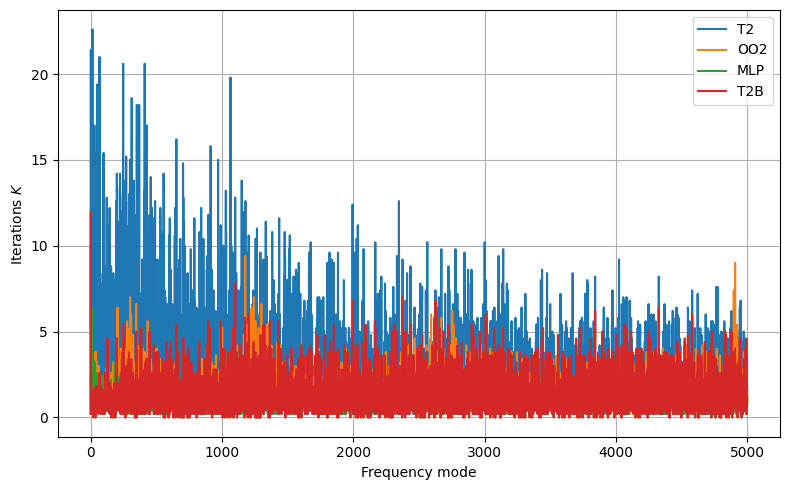

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming the x-axis is just the index of the frequency mode
modes = np.arange(len(num_iters_to_eliminate_mean['t2']))

# Define colors so the lines and shaded regions match perfectly
colors = {'t2': 'C0', 'oo2': 'C1', 'mlp': 'C2', 't2b': 'C3'} # Default matplotlib colors (blue, orange, green)

plt.figure(figsize=(8, 5))

for met, label in zip(['t2', 'oo2', 'mlp', 't2b'], ['T2', 'OO2', 'MLP', 'T2B']):
    mean = np.array(num_iters_to_eliminate_mean[met])
    sd = np.array(num_iters_to_eliminate_sd[met])
    
    # Plot the mean line
    plt.plot(modes, mean, label=label, color=colors[met], alpha=1.0)
    
    # Fill the standard deviation
    # We use np.maximum(..., 0) for the lower bound because iterations cannot be negative!
    # plt.fill_between(modes, 
    #                  np.maximum(mean - sd, 0), 
    #                  mean + sd, 
    #                  color=colors[met], alpha=0.3) # 0.3 alpha gives a nice soft shading

plt.xlabel('Frequency mode')
plt.ylabel("Iterations $K$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

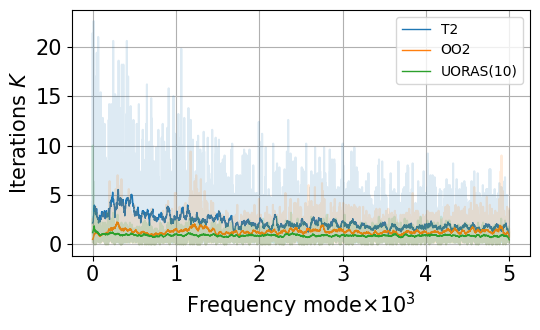

In [15]:
import numpy as np
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 1, figsize=(5.5, 3.4))

# 1. Define a simple moving average function
def get_moving_average(data, window_size):
    box = np.ones(window_size) / window_size
    return np.convolve(data, box, mode='same')

window = 40
modes = np.arange(len(num_iters_to_eliminate_mean['t2']))/1000
colors = {'t2': 'tab:blue', 'oo2': 'tab:orange', 'mlp': 'tab:green'}

for met, label in zip(['t2', 'oo2', 'mlp'], ['T2', 'OO2', r'UORAS(10)']):
    raw_data = np.array(num_iters_to_eliminate_mean[met])
    smoothed_data = get_moving_average(raw_data, window)
    
    plt.plot(modes, raw_data, color=colors[met], alpha=0.15)
    
    plt.plot(modes, smoothed_data, label=f'{label}', 
             color=colors[met], linewidth=1)

plt.xlabel(r'Frequency mode$\times 10^3$', fontsize=15)
plt.ylabel("Iterations $K$", fontsize=15)
plt.legend(fontsize=10)
plt.grid(True)
plt.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.savefig('results_fig/freq.pdf', bbox_inches='tight', pad_inches=0.01)
plt.show()
